In [1]:
import os.path as op
import numpy as np
from scipy import stats as stats
from scipy.stats import pearsonr
from functools import partial
import pandas as pd
import mne
import matplotlib.pyplot as plt
from mne.minimum_norm import make_inverse_operator, apply_inverse, source_band_induced_power, apply_inverse_epochs,compute_source_psd, compute_source_psd_epochs
from mne.datasets import fetch_fsaverage
import pickle
from scipy.stats import sem
from mne import spatial_src_adjacency
from mne.stats import spatio_temporal_cluster_test, summarize_clusters_stc
import xarray as xr

subjects_dir = '/mnt/beegfs/malann/codes/Pain_project/data/mne_data/MNE-fsaverage-data'
subject = "fsaverage"
trans = "fsaverage"  # MNE has a built-in fsaverage transformation
src_fname = subjects_dir+'/'+subject+"/bem"+"/fsaverage-ico-4-src.fif"
bem = subjects_dir+'/'+subject+"/bem"+"/fsaverage-5120-5120-5120-bem-sol.fif"
src = mne.read_source_spaces(src_fname)


import statsmodels.api as sm
import statsmodels.formula.api as smf
from mpl_toolkits.axes_grid1 import ImageGrid, inset_locator, make_axes_locatable
labels = mne.read_labels_from_annot(
        "fsaverage", "aparc", "both", subjects_dir=subjects_dir
    )
labels = [label for label in labels if 'unknown' not in label.name]


# Get valid vertices for both hemispheres
valid_verts = [[], []]
for label in labels:
    hemi_idx = 0 if label.hemi == 'lh' else 1
    valid_verts[hemi_idx].extend(label.vertices)

# Remove duplicates and sort
valid_verts = [np.array(sorted(set(valid_verts[0]))), np.array(sorted(set(valid_verts[1])))]


def mask_stc_vertices(stc, valid_verts):
    """Set data to zero for vertices not in the atlas."""
    masked_data = stc.data.copy()
    offset = 0  # to track row indices in stc.data

    for hemi_idx, hemi_verts in enumerate(stc.vertices):
        invalid_mask = ~np.isin(hemi_verts, valid_verts[hemi_idx])
        for idx, invalid in enumerate(invalid_mask):
            if invalid:
                masked_data[offset + idx, :] = 0  # set entire time/frequency row to zero
        offset += len(hemi_verts)

    stc._data = masked_data
    return stc


    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
Reading labels from parcellation...
   read 35 labels from /mnt/beegfs/malann/codes/Pain_project/data/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.annot
   read 34 labels from /mnt/beegfs/malann/codes/Pain_project/data/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.annot


In [2]:
pain_rating = {'PASP001':5,'PASP002':6,'PASP003':6,'PASP004':6,'PASP005':8,
               'PASP007':5,'PASP008':5,'PASP010':0,'PASP012':3.5, 'PASP013':4,
               'PASP014':5,'PASP015':3,
               'PASP016':7,'PASP017':3,'PASP020':2.5,
               'PASP021': 7,'PASP022':4,'PASP023':4.5,'PASP025':8, 
               'PASP026':5.5, 'PASP027':5,'PASP028':3,'PASP029':6, 'PASP030':7, 'PASP031':5.5,'PASP032':7,'PASP033': 4.5
               }
len(pain_rating)

#'PASP009':6.5,'PASP011':7,'PASP019':7.5, # removed for no alpha peak
# "PASP006", "PASP018" # no pain rating available

27

In [3]:
Control_list1 = ["PASC001", "PASC003", "PASC004", "PASC005", "PASC007", "PASC009", "PASC010",
                "PASC011", "PASC012", "PASC013", "PASC015", "PASC018",
                "PASC019", "PASC020", "PASC022", "PASC023", "PASC024", "PASC025", 
                "PASC027", "PASC028", "PASC029", "PASC030", "PASC032", "PASC033", 
                "PASC034", "PASC035", "PASC036", "PASC037", "PASC038", "PASC039", 
                "PASC040", "PASC041"]
#"PASC014"
Patient_list = ["PASP001", "PASP002", "PASP003", "PASP004", "PASP005", "PASP007", "PASP008", 
                "PASP010", "PASP012", "PASP013", "PASP014", "PASP015", "PASP016", 
                "PASP017", "PASP020", "PASP021", "PASP022", "PASP023", "PASP025", 
                "PASP026", "PASP027", "PASP028", "PASP029", "PASP030", "PASP031",
                "PASP032", "PASP033", "PASP006", "PASP018"]# "PASP009", "PASP011", "PASP019"]
#"PASP009", "PASP011", "PASP019", 

#Control_list = [    "PASC011", "PASC041", "PASC032", "PASC036", "PASC020", "PASC037", "PASC029", 
#                    "PASC035", "PASC033", "PASC013", "PASC005", "PASC019", "PASC027", "PASC022", 
#                    "PASC023", "PASC038", "PASC012"]
#"PASC014"
#Patient_list = ["PASP001", "PASP004", "PASP005", "PASP007", "PASP008", 
#                "PASP010", "PASP012", "PASP015", "PASP016", 
#                "PASP020", "PASP023", "PASP026", "PASP028", 
#                "PASP029", "PASP030", "PASP033", "PASP006"]

Camcan_list = ["CC121411","CC120218","CC220115","CC221886","CC221040","CC221511","CC220974",
               "CC221002","CC221585","CC221220","CC321137","CC320568","CC321595","CC320893",
               "CC320089","CC410323","CC420392","CC420236","CC420396","CC420433","CC410222",
               "CC410173","CC420148","CC410289","CC410297","CC510609","CC520168","CC510551",
               "CC510076","CC510115","CC620405"]

Camcan_list2 = ["CC120319","CC210519","CC221209","CC221595","CC223286","CC210088","CC220999",
                "CC220198","CC222496","CC221352","CC310410","CC320759","CC310463","CC320850",
                "CC320888","CC410015","CC420493","CC420060","CC420623","CC420202","CC420197",
                "CC410179","CC420462","CC410287","CC410243","CC520042","CC510629","CC510242",
                "CC510548","CC510433","CC610227"]


Mixed_list = ["CC320568","CC321595","CC320893","PASC005","CC320089","CC420236","CC420396",
            "PASC011","PASC012","PASC013","CC410173","CC420148","CC410289","PASC019",
            "PASC020","PASC022","PASC023","PASC027","CC510076",
            "PASC029","CC510115","PASC032","PASC033","CC620405","PASC036","PASC035",
            "PASC037","PASC038","PASC041","CC520168","CC510551",]


control_type = 'control'
if control_type == 'camcan':
    Control_list = Camcan_list
if control_type == 'camcan2':
    Control_list = Camcan_list2
if control_type == 'mixed':
    Control_list = Mixed_list
if control_type == 'control':
    Control_list = Control_list1


Control_list_MRI = ["PASC004", "PASC007", "PASC032", "PASC036", "PASC041", "PASC028"]

Patient_list_MRI = ["PASP001", "PASP002", "PASP004","PASP014", "PASP017", "PASP019", "PASP020",
                    "PASP021", "PASP022", "PASP023", "PASP028", "PASP029", "PASP030", "PASP031","PASP033"]
print(len(Patient_list))
print(len(Control_list))
print(len(Camcan_list))


29
32
31


In [4]:
Control_list = [    "PASC011", "PASC041", "PASC032", "PASC036", "PASC020", "PASC037", "PASC029", 
                    "PASC035", "PASC033", "PASC013", "PASC005", "PASC019", "PASC027", "PASC022", 
                    "PASC023", "PASC038", "PASC012"]
#"PASC014"
Patient_list = ["PASP001", "PASP004", "PASP005", "PASP007", "PASP008", 
                "PASP010", "PASP012", "PASP015", "PASP016", 
                "PASP020", "PASP023", "PASP026", "PASP028", 
                "PASP029", "PASP030", "PASP033", "PASP006"]

# Age and Gender Matched
Control_list = ["PASC038","PASC034","PASC011","PASC033",
                "PASC027","PASC013","PASC041","PASC035",
                "PASC037","PASC036","PASC029","PASC032",
                "PASC014","PASC022","PASC005","PASC020",
                "PASC019","PASC023","FASC004","PASC012"]
#,"PASC023"]

Patient_list = ["PASP030","PASP001","PASP005","PASP015",
                "PASP016","PASP026","PASP004","PASP008",
                "PASP012","PASP032","PASP027","PASP013",
                "PASP025","PASP033","PASP007","PASP029",
                "PASP023","PASP020","PASP018","PASP014"]
#,"PASP014"]

print(len(Control_list))
print(len(Patient_list))

20
20


In [5]:
control_stcs = {}
control_PAF = {}
control_PAF_power = {}
control_stc_all = []
control_stcs_raw = {}

avg_stc_control = 0
avg_stc_control1 = 0

patient_stcs = {}
patient_PAF = {}
patient_PAF_power = {}
patient_stc_all = []
patient_stcs_raw = {}

avg_stc_patient = 0
avg_stc_patient1 = 0

PAF_Power_P_all = []
PAF_P_all = []
PAF_Power_P_stcs = []
PAF_P_stcs = []

norm = False

if norm == True:
    nfl, nfh = 1, 40
elif norm == False:
    nfl, nfh = 7, 13   # normalization band for PAF power calculation
fl, fh = 8, 12    # Alpha band


for sub in Control_list[0: len(Patient_list)]:

    if control_type in ['camcan', 'camcan2']:
        psd_dir = f'/mnt/beegfs/malann/codes/Pain_project/results/Cancam_source_PSDs/sub-{sub}/psd/'
        fname_stc= psd_dir+f'sub-{sub}-task-rest-full-psd-fsaverage'   
    elif control_type == 'control':
        psd_dir = "/mnt/beegfs/malann/codes/Pain_project/results/Control_Source_PSDs/"
        fname_stc = psd_dir + sub + "_SPONT_2_psd_dSPM"
    elif control_type == 'mixed':
        
        if sub in Control_list1:
            subjects_dir = "H:/E_drive/Freesurfer_Files"
            psd_dir = "H:/E_drive/Control_Source_PSDs/"
            fname_stc = psd_dir + sub + "_SPONT_2_psd_dSPM"

        elif sub in Camcan_list:
            psd_dir = f'H:/E_drive/Cancam_source_PSDs/sub-{sub}/psd/'
            fname_stc= psd_dir+f'sub-{sub}-task-rest-full-psd-fsaverage'   
    

    subject = 'fsaverage'
    stc = mne.read_source_estimate(fname_stc, subject=subject)
       
    if norm == True:
        stc = stc.copy().crop(nfl, nfh)    
        stc_norm = stc.copy().sum()
        stc = 100 * stc / stc_norm.data
    if norm == False:
        stc_band = stc.copy().crop(nfl, nfh)    
        stc_norm = stc_band.copy().sum()

    
    avg_stc_control += stc
    control_stc_all.append(stc)
    
    stc = mask_stc_vertices(stc, valid_verts)
    
    stc_alpha = stc.copy().crop(fl, fh)
    avg_stc_control1 += stc_alpha
    control_stcs_raw[sub] = stc_alpha

    control_stcs[sub] = stc_alpha.data
    source_time_max1 = np.multiply(stc_alpha.data, stc_alpha.times).sum(axis=1) / stc_alpha.data.sum(axis=1)

    source_vert_max1 = []
    for i, paf in enumerate(source_time_max1):
        if norm == False:
            source_vert_max1.append(100*(stc_alpha.data[i][np.argmin(np.abs(stc_alpha.times - paf))]/stc_norm.data[i])) #/stc_norm.data[i]
        else:
            source_vert_max1.append((stc_alpha.data[i][np.argmin(np.abs(stc_alpha.times - paf))])) #/stc_norm.data[i]
    control_PAF[sub] = np.nanmean(source_time_max1)
    control_PAF_power[sub] = np.nanmean(np.array(source_vert_max1))


for sub in Patient_list:
    psd_dir = "/mnt/beegfs/malann/codes/Pain_project/results/Patient_Source_PSDs/"
    fname_stc = psd_dir + sub + "_SPONT_2_psd_dSPM"

    subject = 'fsaverage'
    stc = mne.read_source_estimate(fname_stc, subject=subject)
    stc_norm = stc.copy().sum()
    if norm == True:
        stc = stc.copy().crop(nfl, nfh)    
        stc_norm = stc.copy().sum()
        stc = 100 * stc / stc_norm.data
    if norm == False:
        stc_band = stc.copy().crop(nfl, nfh)    
        stc_norm = stc_band.copy().sum()

    avg_stc_patient += stc
    patient_stc_all.append(stc)
    
    stc = mask_stc_vertices(stc, valid_verts)



    stc_alpha = stc.copy().crop(fl, fh)
    avg_stc_patient1 += stc_alpha
    patient_stcs_raw[sub] = stc_alpha

    patient_stcs[sub] = stc_alpha.data
    source_time_max1 = np.multiply(stc_alpha.data, stc_alpha.times).sum(axis=1) / stc_alpha.data.sum(axis=1)

    source_vert_max1 = []
    for i, paf in enumerate(source_time_max1):
        if norm == False:
            source_vert_max1.append(100*(stc_alpha.data[i][np.argmin(np.abs(stc_alpha.times - paf))]/stc_norm.data[i])) #/stc_norm.data[i]
        else:
            source_vert_max1.append((stc_alpha.data[i][np.argmin(np.abs(stc_alpha.times - paf))])) #/stc_norm.data[i]
        
    patient_PAF[sub] = np.nanmean(source_time_max1)
    patient_PAF_power[sub] = np.nanmean(np.array(source_vert_max1))


avg_stc_control1 = avg_stc_control1 / len(control_stc_all)
avg_stc_control = avg_stc_control / len(control_stc_all)

avg_stc_patient = avg_stc_patient / len(patient_stc_all)
avg_stc_patient1 = avg_stc_patient1 / len(patient_stc_all)


/tmp/ipykernel_3676328/1160487796.py:75: RuntimeWarning: invalid value encountered in divide
  source_time_max1 = np.multiply(stc_alpha.data, stc_alpha.times).sum(axis=1) / stc_alpha.data.sum(axis=1)
/tmp/ipykernel_3676328/1160487796.py:114: RuntimeWarning: invalid value encountered in divide
  source_time_max1 = np.multiply(stc_alpha.data, stc_alpha.times).sum(axis=1) / stc_alpha.data.sum(axis=1)


PAF: U = 157.000, p = 0.250
PAF control mean = 9.892, std = 0.2635819883249592
PAF Patient mean = 9.814, std = 0.186492969279961
Cohen's d = -0.341
PAF Power: U = 170.000, p = 0.425
PAF Power control mean = 3.608, std = 1.1556494235992432
PAF Power Patient mean = 3.431, std = 1.4138164520263672
Cohen's d = -0.138


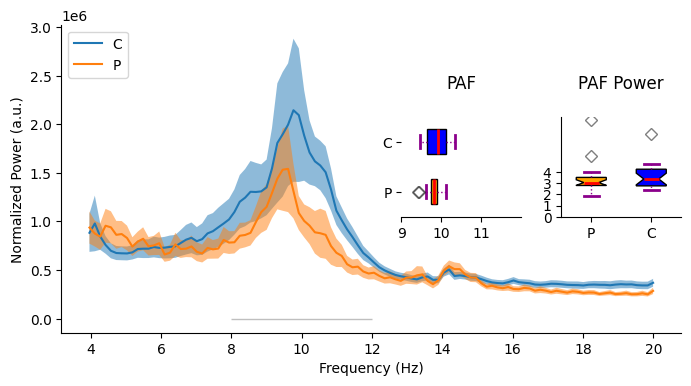

In [6]:
patient_PAF_power_values = np.array(list(patient_PAF_power.values()))
control_PAF_power_values = np.array(list(control_PAF_power.values()))
patient_PAF_values = np.array(list(patient_PAF.values()))
control_PAF_values = np.array(list(control_PAF.values()))

f1, f2 = 4,20 # freqs to plot
freq = avg_stc_control.copy().crop(f1, f2).times

c_sub_avg =[]
for stc in control_stc_all:
    c_sub_avg.append(stc.copy().crop(f1, f2).data.mean(axis = 0))
c_sub_avg = np.array(c_sub_avg)

p_sub_avg =[]
for stc in patient_stc_all:
    p_sub_avg.append(stc.copy().crop(f1, f2).data.mean(axis = 0))
p_sub_avg = np.array(p_sub_avg)

mean_control = np.mean(c_sub_avg,axis=0)
var_control = sem(c_sub_avg,axis=0)

mean_patient = np.mean(p_sub_avg,axis=0)
var_patient = sem(p_sub_avg,axis=0)

fig, ax1 = plt.subplots(figsize=(8, 4))
plt.grid(False)

ax1.plot(freq, mean_control)
ax1.plot(freq, mean_patient)

#ax1.errorbar(freq, mean_control,yerr=var_control,errorevery=(8, 5), capsize=3, capthick=1)
#ax1.errorbar(freq, mean_patient,yerr=var_patient,errorevery=(8, 5), capsize=3, capthick=1)

ax1.fill_between(freq,mean_control+var_control, mean_control-var_control,alpha=0.5)
ax1.fill_between(freq,mean_patient+var_patient, mean_patient-var_patient,alpha=0.5)

ax1.legend(('C', 'P'),
               loc='upper left')

#ax1.set_title('Avg. PSD')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Normalized Power (a.u.)')    
ax1.fill_betweenx(np.linspace(0, 1.6, 100), 8, 12, color='gray', alpha=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)


# Inset plot for PAF 
l, b, h, w = .55, .4, .15, .25
ax2 = fig.add_axes([l, b, h, w])
bp = ax2.boxplot([patient_PAF_values,control_PAF_values],patch_artist = True,widths =0.5,
                notch =False, vert = False)

colors = ['orange','blue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# changing color and linewidth of
# whiskers
for whisker in bp['whiskers']:
    whisker.set(color ='#8B008B',
                linewidth = 1,
                linestyle =":")
# changing color and linewidth of
# caps
for cap in bp['caps']:
    cap.set(color ='#8B008B',
            linewidth = 2)
    
# changing color and linewidth of
# medians
for median in bp['medians']:
    median.set(color ='red',
               linewidth = 2)
# changing style of fliers
for flier in bp['fliers']:
    flier.set(marker ='D',
              color ='#e7298a',
              alpha = 0.5)
ax2.set_yticklabels(['P','C'])
ax2.set_xlim(9, 12)
ax2.set_title('PAF',  pad=20)
ax2.set_xticks([9, 10, 11])  # Explicitly set x-tick positions
ax2.set_xticklabels([9, 10, 11])  # Ensure correct labels
#[st, pval] = stats.ttest_ind(patient_PAF_values,control_PAF_values) # t test between control and patient PAF

from scipy.stats import mannwhitneyu

# Replace t-test for PAF
st, pval = mannwhitneyu(patient_PAF_values, control_PAF_values, alternative='two-sided')
print(f"PAF: U = {st:.3f}, p = {pval:.3f}")

# Calculate the means and standard deviations
mean_patient = np.mean(patient_PAF_values)
mean_control = np.mean(control_PAF_values)
sd_patient = np.std(patient_PAF_values, ddof=1)  # Sample standard deviation
sd_control = np.std(control_PAF_values, ddof=1)  # Sample standard deviation

# Calculate sample sizes
n_patient = len(patient_PAF_values)
n_control = len(control_PAF_values)

# Calculate pooled standard deviation
pooled_sd = np.sqrt(((n_patient - 1) * sd_patient**2 + (n_control - 1) * sd_control**2) / (n_patient + n_control - 2))

# Calculate Cohen's d
cohens_d = (mean_patient - mean_control) / pooled_sd

# Calculate degrees of freedom
df = n_patient + n_control - 2

# Output the results

print(f"PAF control mean = {mean_control:.3f}, std = {sd_control}")
print(f"PAF Patient mean = {mean_patient:.3f}, std = {sd_patient}")
#print(f"t({df}) = {st:.3f}, p = {pval:.3f}, Cohen's d = {cohens_d:.3f}")
print(f"Cohen's d = {cohens_d:.3f}")


if pval<0.05:

    x1, x2 =  11.1, 11.4
    y, h, col = 1, 1, 'k'
    
    ax2.plot([x1, x2, x2, x1], [y, y, y+h, y+h], lw=1.5, c=col)
    ax2.text((x1+x2)*.52, 1.35, f"*", ha='center', va='bottom', color=col)
    
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(True)
ax2.spines['left'].set_visible(False)
plt.grid(False)

#ax2.text((x1+x2)*.52, 1.4, f"* (p={round(pval,3)})", ha='center', va='bottom', color=col)


# Inset plot for PAF power
l, b, h, w = 0.75, .4, .15, .25
ax3 = fig.add_axes([l, b, h, w])
bp = ax3.boxplot([patient_PAF_power_values,control_PAF_power_values],patch_artist = True,widths =0.5,
                notch ='False')

colors = ['orange','blue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# changing color and linewidth of
# whiskers
for whisker in bp['whiskers']:
    whisker.set(color ='#8B008B',
                linewidth = 1,
                linestyle =":")
# changing color and linewidth of
# caps
for cap in bp['caps']:
    cap.set(color ='#8B008B',
            linewidth = 2)
    
# changing color and linewidth of
# medians
for median in bp['medians']:
    median.set(color ='red',
               linewidth = 2)
# changing style of fliers
for flier in bp['fliers']:
    flier.set(marker ='D',
              color ='#e7298a',
              alpha = 0.5)
ax3.set_xticklabels(['P','C'])
ax3.set_title('PAF Power', pad=20)
ax3.set_yticks([0, 1, 2, 3, 4])

#[st, pval] = stats.ttest_ind(patient_PAF_power_values,control_PAF_power_values) # t test between control and patient PAF Power

# Replace t-test for PAF Power
st, pval = mannwhitneyu(patient_PAF_power_values, control_PAF_power_values, alternative='two-sided')
print(f"PAF Power: U = {st:.3f}, p = {pval:.3f}")


# Calculate the means and standard deviations
mean_patient = np.mean(patient_PAF_power_values)
mean_control = np.mean(control_PAF_power_values)
sd_patient = np.std(patient_PAF_power_values, ddof=1)  # Sample standard deviation
sd_control = np.std(control_PAF_power_values, ddof=1)  # Sample standard deviation


# Calculate sample sizes
n_patient = len(patient_PAF_power_values)
n_control = len(control_PAF_power_values)

# Calculate pooled standard deviation
pooled_sd = np.sqrt(((n_patient - 1) * sd_patient**2 + (n_control - 1) * sd_control**2) / (n_patient + n_control - 2))

# Calculate Cohen's d
cohens_d = (mean_patient - mean_control) / pooled_sd

# Calculate degrees of freedom
df = n_patient + n_control - 2

# Output the results

print(f"PAF Power control mean = {mean_control:.3f}, std = {sd_control}")
print(f"PAF Power Patient mean = {mean_patient:.3f}, std = {sd_patient}")
#print(f"t({df}) = {st:.3f}, p = {pval:.3f}, Cohen's d = {cohens_d:.3f}")
print(f"Cohen's d = {cohens_d:.3f}")


if pval<0.05:

    x1, x2 =  1.1, 1.9
    y, h, col = 4, 0.2, 'k'
    
    ax3.plot([x1, x1, x2, x2 ], [y-h,y, y, y-h], lw=1.5, c=col)
    ax3.text((x1+x2)*.5, 4.1, f"*", ha='center', va='bottom', color=col)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(True)
ax3.spines['left'].set_visible(True)
plt.grid(False)
plt.show()


In [8]:
np.array(list(control_stcs.values())).shape

(29, 5124, 28)

In [9]:
n_vertices_fsave, n_times = stc.data.shape
n_subjects1 = len(np.array(list(control_stcs.values())))
n_subjects2 = len(np.array(list(patient_stcs.values())))
tstep = stc.tstep  # time is frequency here since we have source power in stc

X1 = np.array(np.array(list(control_stcs.values())))
X2 = np.array(np.array(list(patient_stcs.values())))

X1 = np.abs(X1)  # only magnitude
X2 = np.abs(X2)  # only magnitude

#    Note that X needs to be a list of multi-dimensional array of shape
#    samples (subjects_k) × time × space, so we permute dimensions

X1 = np.transpose(X1, [0, 2, 1])
X2 = np.transpose(X2, [0, 2, 1])
X = [X1, X2]

In [11]:
from scipy import stats as stats

print("Computing adjacency.")
adjacency = spatial_src_adjacency(src)

# Now let's actually do the clustering. This can take a long time...
# Here we set the threshold quite high to reduce computation,
# and use a very low number of permutations for the same reason.

n_permutations = 10000
p_threshold = 0.01

stat_fun = partial(mne.stats.ttest_ind_no_p, sigma=1e-3)

t_threshold = -stats.distributions.t.ppf(p_threshold / 2., n_subjects1 - 1)

print("Clustering.")
t_obs, clusters, cluster_p_values, H0 = clu = mne.stats.permutation_cluster_test(
    X,
    adjacency=adjacency,
    stat_fun=stat_fun,
    n_jobs=None,
    threshold=t_threshold,
    n_permutations=n_permutations,
    verbose=True,
    buffer_size=None
)


#    Now select the clusters that are sig. at p < 0.05 (note that this value
#    is multiple-comparisons corrected).
good_cluster_inds = np.where(cluster_p_values < 0.05)[0]


Computing adjacency.
-- number of adjacent vertices : 5124
Clustering.
stat_fun(H1): min=-2.564072847366333 max=3.9809348583221436
Running initial clustering …
Found 34 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

In [12]:
good_cluster_inds, t_threshold

(array([1, 2, 7]), np.float64(2.763262455461066))

In [13]:
from mne import SourceEstimate
fsave_vertices = [np.arange(2562), np.arange(2562)]

# Mask with all significant clusters
t_obs_sig = np.zeros_like(t_obs)
for idx in good_cluster_inds:
    t_obs_sig[clusters[idx]] = t_obs[clusters[idx]]
#t_obs_sig.reshape(t_obs_sig.shape[0],1,t_obs_sig.shape[1])

# Construct the STC
stc_tvals_sig = SourceEstimate(
    t_obs_sig.T,  # single time point
    vertices=fsave_vertices,
    tmin=0,
    tstep=1,
    subject='fsaverage'
)


In [14]:
print("Visualizing clusters.")

#    Now let's build a convenient representation of each cluster, where each
#    cluster becomes a "time point" in the SourceEstimate
fsave_vertices = [np.arange(2562), np.arange(2562)]
stc_all_cluster_vis = summarize_clusters_stc(
    clu,  p_thresh=0.05, tstep=tstep, vertices=fsave_vertices, subject="fsaverage"
)

#    Let's actually plot the first "time point" in the SourceEstimate, which
#    shows all the clusters, weighted by duration

stc_all_cluster_vis.save(f'stat_file_try_01_10000_sub_{len(Patient_list)}', overwrite=True)
stc_tvals_sig.save(f'stat_t_val_try_01_10000_sub_{len(Patient_list)}', overwrite=True)
"""
# blue blobs are for condition A != condition B
brain = stc_all_cluster_vis.plot(
    "fsaverage",
    hemi="both",
    views="dorsal",
    subjects_dir=subjects_dir,
    initial_time=0,
    background="w",

    time_label="temporal extent (ms)",
)
brain.add_annotation("aparc", borders=2)
"""


Visualizing clusters.
Writing STC to disk...
[done]
Writing STC to disk...
[done]


'\n# blue blobs are for condition A != condition B\nbrain = stc_all_cluster_vis.plot(\n    "fsaverage",\n    hemi="both",\n    views="dorsal",\n    subjects_dir=subjects_dir,\n    initial_time=0,\n    background="w",\n\n    time_label="temporal extent (ms)",\n)\nbrain.add_annotation("aparc", borders=2)\n'

In [33]:
stc_all_cluster_vis = mne.read_source_estimate(f'stat_file_05_10000_sub_{len(Patient_list)}')

In [34]:
stc_all_cluster_vis.data

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]], shape=(5124, 2), dtype=float32)